In [3]:
import pennylane as qp
from pennylane import numpy as np
from matplotlib import pyplot as plt

In [4]:
import sympy as sp

# Binary variables
x1, x2, z = sp.symbols("x1 x2 z")

# Your QUBO / penalty Hamiltonian
P = x1*x2 - 2*x1*z - 2*x2*z + 3*z

print("QUBO:")
print(P)

# Convert x_i -> (1 - Z_i)/2
Z0, Z1, Z2 = sp.symbols("Z0 Z1 Z2")

ising = P.subs({
    x1: (1 - Z0)/2,
    x2: (1 - Z1)/2,
    z:  (1 - Z2)/2
})

ising = sp.expand(ising)

print("\nIsing Hamiltonian:")
print(ising)

QUBO:
x1*x2 - 2*x1*z - 2*x2*z + 3*z

Ising Hamiltonian:
Z0*Z1/4 - Z0*Z2/2 + Z0/4 - Z1*Z2/2 + Z1/4 - Z2/2 + 3/4


In [5]:
H_sol = qp.Hamiltonian([1/4, -1/2, 1/4, -1/2, 1/4, -1/2], 
                       [qp.PauliZ(0) @ qp.PauliZ(1), 
                        qp.PauliZ(0) @ qp.PauliZ(2),
                        qp.PauliZ(0),
                        qp.PauliZ(1) @ qp.PauliZ(2),
                        qp.PauliZ(1),
                        qp.PauliZ(2)])

H_mix = qp.Hamiltonian([1, 1, 1], 
                       [qp.PauliX(0),
                        qp.PauliX(1),
                        qp.PauliX(2)])
H_sol, H_mix


((
     0.25 * (Z(0) @ Z(1))
   + -0.5 * (Z(0) @ Z(2))
   + 0.25 * Z(0)
   + -0.5 * (Z(1) @ Z(2))
   + 0.25 * Z(1)
   + -0.5 * Z(2)
 ),
 1 * X(0) + 1 * X(1) + 1 * X(2))

In [6]:
dev = qp.device("default.qubit")

In [7]:
def qaoa_layer(gamma, alpha):
    qp.qaoa.cost_layer(gamma, H_sol)
    qp.qaoa.mixer_layer(alpha, H_mix)

In [8]:
wires = range(3)
depth = 2


def circuit(params, **kwargs):
    for w in wires:
        qp.Hadamard(wires=w)
    qp.layer(qaoa_layer, depth, params[0], params[1])

In [9]:
@qp.qnode(dev)

def cost_function(params):
    circuit(params)
    return qp.expval(H_sol)

In [10]:
optimizer = qp.GradientDescentOptimizer()
steps = 70
params = np.array([[0.5, 0.5], [0.5, 0.5]], requires_grad=True)

In [11]:
for i in range(steps):
    params = optimizer.step(cost_function, params)

print("Optimal Parameters")
print(params)

Optimal Parameters
[[ 0.55085354 -0.2561659 ]
 [ 0.53477117  0.68899459]]


In [12]:
@qp.qnode(dev)
def probability_circuit(gamma, alpha):
    circuit([gamma, alpha])
    return qp.probs(wires=wires)


probs = probability_circuit(params[0], params[1])

In [13]:
probs

tensor([0.21693398, 0.00406645, 0.10505803, 0.15992168, 0.10505803,
        0.15992168, 0.0166977 , 0.23234243], requires_grad=True)

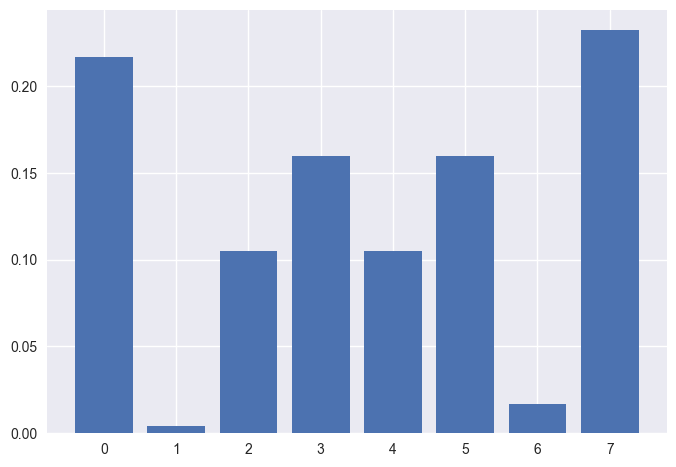

In [14]:
plt.style.use("seaborn-v0_8")
plt.bar(range(2 ** len(wires)), probs)
plt.show()